In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


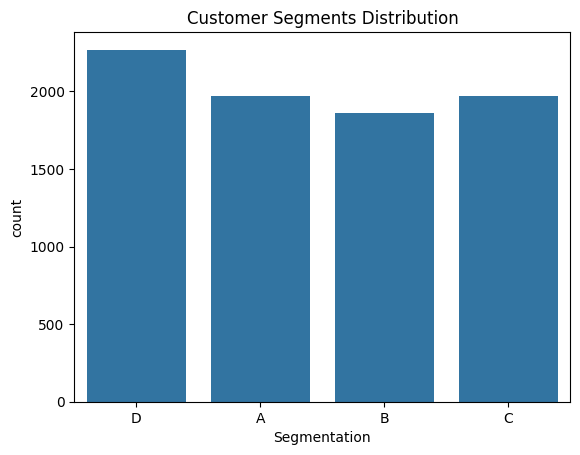

In [4]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

# Preview
train.head()

train.info()
train.describe()

# Check missing values
train.isnull().sum()

# Distribution of target variable
sns.countplot(x="Segmentation", data=train)
plt.title("Customer Segments Distribution")
plt.show()

In [5]:
#preprocessing the data
X = train.drop(columns=["Segmentation"])
y = train["Segmentation"]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Numeric: Index(['ID', 'Age', 'Work_Experience', 'Family_Size'], dtype='object')
Categorical: Index(['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score',
       'Var_1'],
      dtype='object')


In [6]:
#split the train/test data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
#LOGISTIC REGRESSION MODEL
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_val)

print("Baseline Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Baseline Accuracy: 0.5161090458488228
              precision    recall  f1-score   support

           A       0.41      0.44      0.43       394
           B       0.41      0.25      0.31       372
           C       0.51      0.59      0.55       394
           D       0.65      0.74      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.50      0.52      0.50      1614



In [8]:
#RANDOM FOREST MODEL
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Random Forest Accuracy: 0.5266418835192069
              precision    recall  f1-score   support

           A       0.45      0.45      0.45       394
           B       0.39      0.35      0.37       372
           C       0.57      0.56      0.57       394
           D       0.65      0.71      0.68       454

    accuracy                           0.53      1614
   macro avg       0.51      0.52      0.52      1614
weighted avg       0.52      0.53      0.52      1614



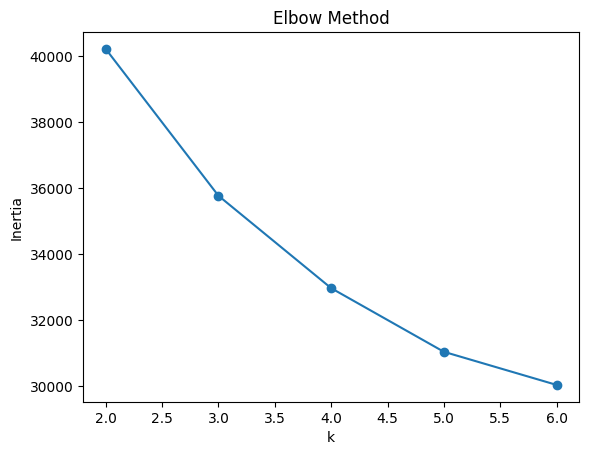

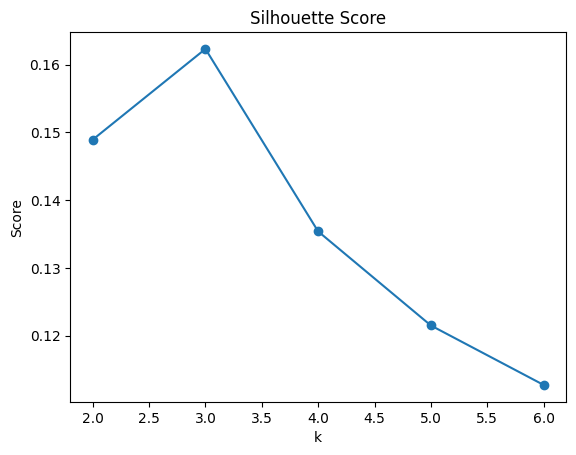

In [17]:
#K-means clustering
X_train_processed = preprocessor.fit_transform(X_train)
inertia = []
sil_scores = []

K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_train_processed)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train_processed, clusters))

# Plot Elbow
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

# Plot Silhouette
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

In [18]:
# fit for final k means - k=4
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_train_processed)
# Add cluster labels to original data
X_train = X_train.copy()
X_train["Cluster"] = clusters

In [ ]:
# PCA visualization 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_processed)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("Customer Clusters (PCA)")
plt.show()

In [20]:
# final retrain of a hybrid model
#1. Start from original split
X_train_c = X_train.copy()
X_val_c = X_val.copy()

# 2. Preprocess training data only
X_train_processed = preprocessor.fit_transform(X_train)

# 3. Fit KMeans on training data only
kmeans = KMeans(n_clusters=4, random_state=42)
train_clusters = kmeans.fit_predict(X_train_processed)

# 4. Transform validation data using the SAME preprocessor
X_val_processed = preprocessor.transform(X_val)

# 5. Predict validation clusters using the SAME KMeans model
val_clusters = kmeans.predict(X_val_processed)

# 6. Add clusters as a new feature
X_train_c["Cluster"] = train_clusters
X_val_c["Cluster"] = val_clusters

hybrid_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

hybrid_model.fit(X_train_c, y_train)

y_pred_hybrid = hybrid_model.predict(X_val_c)

print("Hybrid Model Accuracy:", accuracy_score(y_val, y_pred_hybrid))
print(classification_report(y_val, y_pred_hybrid))

Hybrid Model Accuracy: 0.5266418835192069
              precision    recall  f1-score   support

           A       0.45      0.45      0.45       394
           B       0.39      0.35      0.37       372
           C       0.57      0.56      0.57       394
           D       0.65      0.71      0.68       454

    accuracy                           0.53      1614
   macro avg       0.51      0.52      0.52      1614
weighted avg       0.52      0.53      0.52      1614

